[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/nmickevicius/MCW_BIOP_03-238_MRI/blob/main/22_B0_cartesian_vs_radial/simulate_cartesian_radial.ipynb)

In [ ]:
# if running in Google Colab, torchkbnufft will need to be installed 
!pip install torchkbnufft

In [ ]:
import numpy as np 
import torch 
import torchkbnufft as tkbn 
import matplotlib.pyplot as plt 
import scipy.io as sio 

device = torch.device('cpu') # change to 'cuda:0' if you have an NVIDIA GPU available 

# gyromagnetic ratio [Hz/T]
gb = 42.577e6

fft2d = lambda inp, dims: torch.fft.fftshift(torch.fft.fft2(torch.fft.ifftshift(inp, dim=dims), dim=dims), dim=dims)
ifft2d = lambda inp, dims: torch.fft.fftshift(torch.fft.ifft2(torch.fft.ifftshift(inp, dim=dims), dim=dims), dim=dims)


# load a digital phantom to use in simulation 
# fname = '/Users/nmickevicius/dev/MCW_BIOP_03-238_MRI/data/brain_relaxometry_3T.mat'
!wget https://github.com/nmickevicius/MCW_BIOP_03-238_MRI/raw/main/data/brain_relaxometry_3T.mat
fname = os.path.join(os.getcwd(), 'brain_relaxometry_3T.mat')
df = sio.loadmat(fname)
obj = df['PD'].astype(np.float32)[::2, ::2, 90]
obj = torch.tensor(obj, dtype=torch.float32, device=device)
N = obj.shape[0]

# image field of view 
fov = 0.2 # meters 

# readout bandwidth and oversampling factor 
osf = 1.5 
adc_dwell_time = 16e-6 # includes oversampling!!!!!

# x and y coordinate values in each pixel
xv = torch.tensor(np.linspace(-fov/2, fov/2, N, endpoint=False), dtype=torch.float32, device=device) + 0.5*fov/N
Y,X = torch.meshgrid(xv, xv, indexing='ij')

# make a delta B0 distribution (linear function of x for simplicity)
delta_B0_max = 200.0 # Hz
B0x = torch.linspace(-delta_B0_max, delta_B0_max, N)
B0 = torch.stack([B0x]*N, dim=0)

# get radial spoke angles 
nproj = int(np.pi * N)
proj_angles = torch.tensor(np.linspace(0.0, 2*np.pi, nproj), dtype=torch.float32, device=device) 
nr = int(osf * N)
kr = torch.tensor(np.linspace(-N/2, N/2, nr, endpoint=False) / fov, dtype=torch.float32, device=device) + 0.5/fov

# density compensation function 
dcf = torch.abs(torch.linspace(-1, 1, nr, dtype=torch.float32, device=device))

# make the k-space trajectory for each spoke angle 
kx = torch.cos(proj_angles[None,:]) * kr[:,None]
ky = torch.sin(proj_angles[None,:]) * kr[:,None] 
kx_traj = np.pi * kx / (N/2/fov)
ky_traj = np.pi * ky / (N/2/fov)
ktraj = torch.stack([ky_traj.flatten(), kx_traj.flatten()], dim=0)
dcf = torch.stack([dcf]*nproj, dim=-1).flatten()
adj_nufft = tkbn.KbNufftAdjoint(im_size=(N,N)).to(device)

# cartesian k-space trajectory for comparison 
kr = torch.tensor(np.linspace(-N/2, N/2, N, endpoint=False) / fov, dtype=torch.float32, device=device) 
ky_cart, kx_cart = torch.meshgrid(kr, kr, indexing='ij')

# calculate x and y gradient amplitudes for each spoke angle 
G = (1/fov) / (gb * adc_dwell_time)
print(f'Readout gradient amplitude: {G*1e3} mT/m')
Grx = G * torch.cos(proj_angles)
Gry = G * torch.sin(proj_angles) 
Grx[Grx == 0.0] = 1e9 # when Grx is zero, kx is zero anyway, so this is just to avoid dividing by zero
Gry[Gry == 0.0] = 1e9 # when Gry is zero, ky is zero anyway, so this is just to avoid dividing by zero

# simulate radial k-space data and reconstruct image 
ksp = torch.sum( obj[None,None,:,:] * torch.exp(-1j*2*np.pi*(kx[:,:,None,None] * (X[None,None,:,:] + B0[None,None,:,:]/(gb * Grx[None,:,None,None])) + ky[:,:,None,None] * (Y[None,None,:,:] + B0[None,None,:,:]/(gb * Gry[None,:,None,None])))), dim=(-1,-2))
data = ksp.flatten()*dcf
img_radial = adj_nufft(data[None,None,...], ktraj)[0,0,:,:]

# cartesian (gradient is along +y)
ksp = torch.sum(obj[None,None,:,:] * torch.exp(-1j*2*np.pi*(kx_cart[:,:,None,None] * X[None,None,:,:] + ky_cart[:,:,None,None] * (Y[None,None,:,:] + B0[None,None,:,:]/(gb * G)))), dim=(-1,-2))
img_cart = ifft2d(ksp, (0,1))



Readout gradient amplitude: 7.339643469478827 mT/m


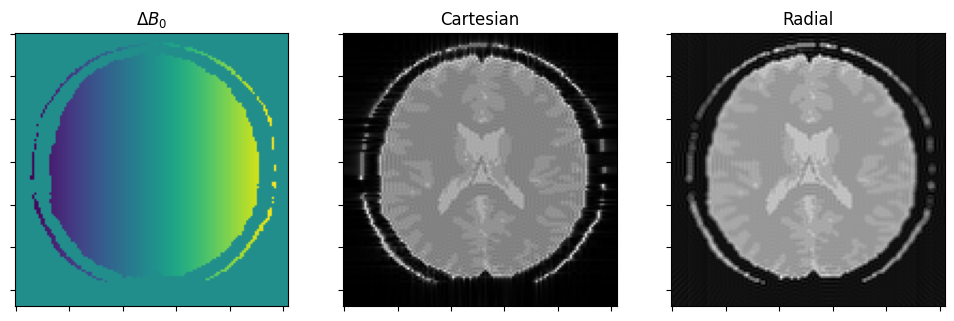

In [25]:
fig, ax = plt.subplots(1,3, figsize=(12,5))
ax[0].imshow(B0 * (obj > 0.0).to(torch.float32), cmap='viridis')
ax[0].set_title('$\Delta B_0$')
ax[0].set_xticklabels([])
ax[0].set_yticklabels([])
ax[2].imshow(torch.abs(img_radial.cpu()), cmap='gray')
ax[2].set_title('Radial')
ax[2].set_xticklabels([])
ax[2].set_yticklabels([])
ax[1].imshow(torch.abs(img_cart.cpu()), cmap='gray')
ax[1].set_title('Cartesian')
ax[1].set_xticklabels([])
ax[1].set_yticklabels([])
plt.show()